Regiones y Fronteras

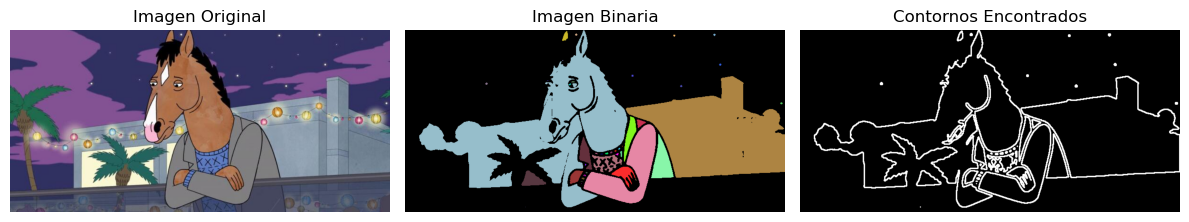

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #siempre convertir a escala de grises
#combiar tecnicas para preparar la imagen 
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#encontramos las regiones 
num_l, label = cv2.connectedComponents(binary)
#identificar por colores 
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
#fondo negro
color[0] = [0, 0, 0]
colorear = color[label]
#encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255,2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Imagen Binaria')
plt.imshow(colorear)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Contornos Encontrados')
plt.imshow(contorno_fin, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


Conteo

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img = measure.label(binary, connectivity=2) 
    #2 = conectividad es de 4 elementos( arriba, abajo, izquierda, derecha) 
    #cuando es 1 es de 8 elementos (arriba, abajo, izquierda, derecha y las diagonales)
    num_obj = np.max(e_img)
    return num_obj

image = cv2.imread('imagen1.jpg')
num_elementos = contar_elementos(image)
print(f'Número de elementos encontrados: {num_elementos}')

#mostrar imagen
plt.figure(figsize=(6, 6))
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# regiones
num_l, label = cv2.connectedComponents(binary)
num_regiones = max(0, num_l - 1) 

# fronteras 
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
num_fronteras = len(contornos)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

# elementos
e_img = measure.label(binary > 0, connectivity=2)
num_elementos = int(np.max(e_img))

print(f"Regiones (sin fondo): {num_regiones}")
print(f"Fronteras (contours encontrados): {num_fronteras}")
print(f"Elementos (skimage.label): {num_elementos}")

color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
if num_l > 0:
    color[0] = [0, 0, 0]
colorear = color[label]

plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1); plt.title('Original'); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1, 4, 2); plt.title('Binaria'); plt.imshow(binary, cmap='gray'); plt.axis('off')
plt.subplot(1, 4, 3); plt.title('Regiones Coloreadas'); plt.imshow(colorear); plt.axis('off')
plt.subplot(1, 4, 4); plt.title('Contornos'); plt.imshow(contorno_fin, cmap='gray'); plt.axis('off')
plt.tight_layout(); plt.show()